# POMO — Policy Optimization with Multiple Optima
### TSP classique — implémentation multi-départ + 2-opt

**Principe POMO :** au lieu d'une seule solution construite depuis le dépôt, on lance $n$ constructions gloutonnes en parallèle — une par ville de départ possible. On conserve la meilleure. Cela exploite la **symétrie rotationnelle** du TSP : toute rotation d'un tour optimal reste optimale, donc chaque point de départ peut conduire à un optimum local différent.

**Pipeline :**
1. Charger l'instance depuis `datasets/tsptwd_n*.json`
2. Construire le graphe complet $G$ avec poids = distance euclidienne brute
3. **POMO :** $n$ départs × Nearest-Neighbor glouton → garder le meilleur tour
4. **2-opt :** amélioration locale par échanges d'arêtes
5. Benchmark sur toutes les tailles disponibles

In [2]:
import json
import math
import time
import random
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

random.seed(42)
np.random.seed(42)

DATASETS_DIR = Path("datasets")

---
## 1. Chargement du dataset et construction du graphe

Chaque fichier JSON expose :
- `depot` — nœud 0, point de départ/retour
- `clients` — nœuds 1…n, champs `id, x, y`

Le graphe $G$ est **complet** : on crée une arête entre chaque paire de nœuds avec comme poids la **distance euclidienne brute** (avant le ×200). Le facteur d'échelle est appliqué uniquement dans `tour_cost`.

In [3]:
def load_dataset(path: Path) -> dict:
    """Charge un fichier JSON du dossier datasets/."""
    with open(path) as f:
        return json.load(f)


def build_graph(data: dict) -> tuple[nx.Graph, list[dict]]:
    """
    Construit le graphe complet G à partir d'un dataset.

    Les poids des arêtes sont les distances euclidiennes BRUTES (sans ×200).
    Le facteur d'échelle est appliqué uniquement dans tour_cost.

    Retourne (G, nodes) où nodes est la liste [depot] + clients.
    """
    nodes = [data["depot"]] + data["clients"]
    G = nx.Graph()

    for node in nodes:
        G.add_node(node["id"], x=node["x"], y=node["y"])

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u, v = nodes[i], nodes[j]
            dist = math.sqrt((u["x"] - v["x"]) ** 2 + (u["y"] - v["y"]) ** 2)
            G.add_edge(u["id"], v["id"], weight=dist)

    return G, nodes


# ── Vérification rapide ────────────────────────────────────────────────────
data_n10 = load_dataset(DATASETS_DIR / "tsptwd_n10.json")
G10, nodes10 = build_graph(data_n10)

print(f"Nœuds : {G10.number_of_nodes()}  (1 dépôt + {len(data_n10['clients'])} clients)")
print(f"Arêtes : {G10.number_of_edges()}  (graphe complet)")
sample_edge = list(G10.edges(data=True))[0]
print(f"Exemple d'arête {sample_edge[0]}→{sample_edge[1]} : poids brut = {sample_edge[2]['weight']:.4f}"
      f"  →  coût ×200 = {sample_edge[2]['weight']*200:.2f}")

Nœuds : 11  (1 dépôt + 10 clients)
Arêtes : 55  (graphe complet)
Exemple d'arête 0→1 : poids brut = 0.6547  →  coût ×200 = 130.95


---
## 2. Fonction de coût

$$\text{tour\_cost}(G, h) = \left(\sum_{i=0}^{|h|-2} w(h_i, h_{i+1})\right) \times 200$$

Le tour hamiltonien $h$ est une liste de la forme $[0, c_1, c_2, \ldots, c_n, 0]$.

In [4]:
def tour_cost(G: nx.Graph, hamiltonian: list[int], scale: float = 200) -> float:
    return round(
        sum(G[hamiltonian[i]][hamiltonian[i + 1]]["weight"]
            for i in range(len(hamiltonian) - 1)) * scale,
        1,
    )

---
## 3. Algorithme POMO

### Nearest-Neighbor glouton (base)

À chaque étape, on visite la ville non-visitée la plus proche. Complexité : $O(n^2)$.

### POMO : multi-départ

On lance la construction NN depuis **chaque ville** possible comme premier nœud.  
Pour $n$ villes on obtient $n$ tours candidats — on garde le meilleur.  
Complexité totale : $O(n^3)$.

La **symétrie rotationnelle** du TSP garantit que le tour optimal est atteignable depuis n'importe quelle ville de départ ; POMO exploite cette propriété pour diversifier la recherche.

In [5]:
def _greedy_nn(G: nx.Graph, all_node_ids: list[int], start: int) -> list[int]:
    """
    Construction Nearest-Neighbor depuis `start`.
    Retourne un tour cyclique : [start, ..., start].
    """
    unvisited = set(all_node_ids) - {start}
    tour = [start]
    current = start
    while unvisited:
        nearest = min(unvisited, key=lambda v: G[current][v]["weight"])
        tour.append(nearest)
        unvisited.remove(nearest)
        current = nearest
    tour.append(start)  # retour au point de départ
    return tour


def _normalize_tour(tour: list[int], depot: int = 0) -> list[int]:
    """
    Rotation du tour cyclique pour qu'il commence et finisse au dépôt.
    [a, b, 0, c, d, a]  →  [0, c, d, a, b, 0]
    """
    cycle = tour[:-1]  # retire le doublon final
    if cycle[0] == depot:
        return cycle + [depot]
    idx = cycle.index(depot)
    return cycle[idx:] + cycle[:idx] + [depot]


def pomo(
    G: nx.Graph,
    all_node_ids: list[int],
    depot: int = 0,
    n_starts: int | None = None,
    scale: float = 200,
) -> tuple[list[int], float]:
    """
    POMO — Policy Optimization with Multiple Optima (version classique).

    Lance n_starts constructions NN depuis des villes de départ différentes
    et retourne le meilleur tour normalisé [depot, ..., depot].

    Paramètres
    ----------
    n_starts : None → utilise toutes les villes (POMO complet, O(n³))
               int  → tire n_starts villes au hasard (utile pour grands n)
    """
    if n_starts is None or n_starts >= len(all_node_ids):
        starts = all_node_ids
    else:
        starts = random.sample(all_node_ids, n_starts)

    best_tour: list[int] = []
    best_cost = float("inf")

    for start in starts:
        raw_tour = _greedy_nn(G, all_node_ids, start)
        tour = _normalize_tour(raw_tour, depot)
        cost = tour_cost(G, tour, scale)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


# ── Test sur n=10 ─────────────────────────────────────────────────────────
node_ids10 = [n["id"] for n in nodes10]
tour10, cost10 = pomo(G10, node_ids10)

print(f"Tour POMO (n=10) : {tour10}")
print(f"Coût             : {cost10}")

Tour POMO (n=10) : [0, 5, 3, 7, 1, 2, 4, 10, 6, 9, 8, 0]
Coût             : 478.7


---
## 4. Amélioration locale — 2-opt

Le 2-opt sélectionne deux arêtes $(i, i+1)$ et $(j, j+1)$ et les échange en inversant le segment $[i+1 \ldots j]$.  
On accepte un échange si et seulement s'il réduit le coût total.

$$\Delta = w(i,j) + w(i{+}1,\,j{+}1) - w(i,\,i{+}1) - w(j,\,j{+}1)$$

Complexité : $O(n^2)$ par passe, $O(n^2 k)$ au total ($k$ = nombre d'itérations jusqu'à convergence).

> Pour les très grandes instances ($n \geq 1000$), l'amélioration 2-opt est désactivée (trop coûteuse).

In [6]:
def two_opt(
    G: nx.Graph,
    tour: list[int],
    scale: float = 200,
    max_iter: int = 500,
) -> tuple[list[int], float]:
    """
    Amélioration 2-opt d'un tour hamiltonien.

    Après chaque échange accepté on repart du début des deux boucles
    (comportement standard 2-opt) pour éviter toute incohérence d'index.
    Le coût final est recalculé exactement via tour_cost.
    """
    best = list(tour)
    n = len(best) - 1  # nombre de villes (tour[0] == tour[-1])

    for _ in range(max_iter):
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                delta = (
                    G[best[i]][best[j]]["weight"]
                    + G[best[i + 1]][best[j + 1]]["weight"]
                    - G[best[i]][best[i + 1]]["weight"]
                    - G[best[j]][best[j + 1]]["weight"]
                )
                if delta < -1e-9:
                    best[i + 1 : j + 1] = best[i + 1 : j + 1][::-1]
                    improved = True
                    break  # on repart de i
            if improved:
                break  # on repart de la passe entière
        if not improved:
            break

    # Recalcul exact pour éviter l'accumulation d'erreurs flottantes
    return best, tour_cost(G, best, scale)


def pomo_2opt(
    G: nx.Graph,
    all_node_ids: list[int],
    depot: int = 0,
    n_starts: int | None = None,
    scale: float = 200,
) -> tuple[list[int], float]:
    """POMO suivi d'une amélioration 2-opt sur le meilleur tour."""
    tour, _ = pomo(G, all_node_ids, depot=depot, n_starts=n_starts, scale=scale)
    return two_opt(G, tour, scale=scale)


# ── Test sur n=10 ─────────────────────────────────────────────────────────
tour10_2opt, cost10_2opt = pomo_2opt(G10, node_ids10)

print(f"Tour POMO+2opt (n=10) : {tour10_2opt}")
print(f"Coût POMO             : {cost10}")
print(f"Coût POMO+2opt        : {cost10_2opt}")
print(f"Gain 2-opt            : {cost10 - cost10_2opt:.1f}")

Tour POMO+2opt (n=10) : [0, 5, 3, 7, 1, 2, 4, 10, 6, 9, 8, 0]
Coût POMO             : 478.7
Coût POMO+2opt        : 478.7
Gain 2-opt            : 0.0


---
## 5. Visualisation du tour (n=10)

Comparaison du tour avant/après amélioration 2-opt.

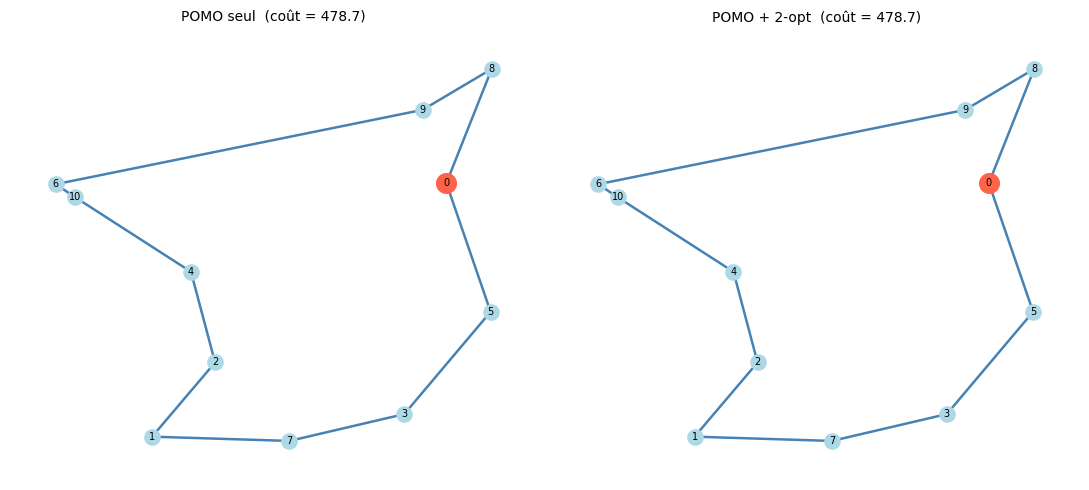

In [7]:
def plot_tour(G: nx.Graph, tour: list[int], title: str = "", ax=None):
    """Trace un tour hamiltonien sur le plan cartésien."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    pos = {n: (G.nodes[n]["x"], G.nodes[n]["y"]) for n in G.nodes}

    # Arêtes du tour
    edges = [(tour[i], tour[i + 1]) for i in range(len(tour) - 1)]
    nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                           edge_color="steelblue", width=1.8, arrows=False)

    # Nœuds
    depot_node = [tour[0]]
    client_nodes = [n for n in G.nodes if n != tour[0]]
    nx.draw_networkx_nodes(G, pos, nodelist=client_nodes, ax=ax,
                           node_size=120, node_color="lightblue")
    nx.draw_networkx_nodes(G, pos, nodelist=depot_node, ax=ax,
                           node_size=200, node_color="tomato")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)

    ax.set_title(title, fontsize=10)
    ax.axis("off")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
plot_tour(G10, tour10,      f"POMO seul  (coût = {cost10})",       ax1)
plot_tour(G10, tour10_2opt, f"POMO + 2-opt  (coût = {cost10_2opt})", ax2)
plt.tight_layout()
plt.show()

---
## 6. Benchmark — toutes les tailles

On mesure pour chaque taille de dataset disponible :

| Méthode | Complexité |
|---------|-----------|
| **NN (1 départ depuis dépôt)** | $O(n^2)$ |
| **POMO (tous les départs)** | $O(n^3)$ — limité à $n \leq 500$ |
| **POMO + 2-opt** | $O(n^3 + n^2 k)$ — limité à $n \leq 500$ |

Pour $n \geq 1000$, seul le NN mono-départ est mesuré (POMO avec `n_starts=100` aléatoires).

In [8]:
POMO_FULL_LIMIT  = 500   # au-delà : POMO avec n_starts aléatoires
POMO_LARGE_STARTS = 100  # départs pour les grandes instances
TWO_OPT_LIMIT    = 500   # au-delà : 2-opt désactivé

dataset_files = sorted(DATASETS_DIR.glob("tsptwd_n*.json"),
                       key=lambda p: int(p.stem.split("_n")[1]))

results = []

for path in dataset_files:
    data = load_dataset(path)
    n = data["meta"]["n_clients"]
    G, nodes = build_graph(data)
    node_ids = [nd["id"] for nd in nodes]
    depot = 0
    scale = 200

    print(f"\n── n={n} ─────────────────────────────────")

    # ── Nearest-Neighbor (1 départ : dépôt) ──────────────────────────────
    t0 = time.perf_counter()
    tour_nn_raw = _greedy_nn(G, node_ids, depot)
    tour_nn = _normalize_tour(tour_nn_raw, depot)
    cost_nn = tour_cost(G, tour_nn, scale)
    t_nn = time.perf_counter() - t0
    print(f"  NN          coût={cost_nn:>10.1f}   t={t_nn:.3f}s")

    # ── POMO ─────────────────────────────────────────────────────────────
    n_starts = None if n <= POMO_FULL_LIMIT else POMO_LARGE_STARTS
    t0 = time.perf_counter()
    tour_pomo, cost_pomo = pomo(G, node_ids, depot=depot,
                                n_starts=n_starts, scale=scale)
    t_pomo = time.perf_counter() - t0
    tag = f"(all {n} starts)" if n_starts is None else f"({n_starts} rand. starts)"
    print(f"  POMO {tag:<22} coût={cost_pomo:>10.1f}   t={t_pomo:.3f}s")

    # ── POMO + 2-opt ─────────────────────────────────────────────────────
    if n <= TWO_OPT_LIMIT:
        t0 = time.perf_counter()
        tour_p2, cost_p2 = two_opt(G, tour_pomo, scale=scale)
        t_p2 = time.perf_counter() - t0
        print(f"  POMO+2opt                        coût={cost_p2:>10.1f}   t={t_p2:.3f}s")
    else:
        cost_p2, t_p2 = None, None
        print(f"  POMO+2opt   skipped (n > {TWO_OPT_LIMIT})")

    results.append({
        "n": n,
        "cost_nn":     cost_nn,      "t_nn":     round(t_nn, 4),
        "cost_pomo":   cost_pomo,    "t_pomo":   round(t_pomo, 4),
        "cost_pomo2":  cost_p2,      "t_pomo2":  round(t_p2, 4) if t_p2 else None,
    })


── n=10 ─────────────────────────────────
  NN          coût=     535.3   t=0.000s
  POMO (all 10 starts)        coût=     478.7   t=0.000s
  POMO+2opt                        coût=     478.7   t=0.000s

── n=50 ─────────────────────────────────
  NN          coût=    1479.2   t=0.000s
  POMO (all 50 starts)        coût=    1440.4   t=0.017s
  POMO+2opt                        coût=    1331.4   t=0.009s

── n=100 ─────────────────────────────────
  NN          coût=    2033.5   t=0.001s
  POMO (all 100 starts)       coût=    1786.5   t=0.127s
  POMO+2opt                        coût=    1698.5   t=0.050s

── n=200 ─────────────────────────────────
  NN          coût=    2705.2   t=0.006s
  POMO (all 200 starts)       coût=    2582.2   t=1.029s
  POMO+2opt                        coût=    2207.8   t=0.710s

── n=300 ─────────────────────────────────
  NN          coût=    3505.1   t=0.014s
  POMO (all 300 starts)       coût=    3181.8   t=3.952s
  POMO+2opt                        coût=    

In [9]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────
df = pd.DataFrame(results).set_index("n")

# Gain relatif POMO vs NN
df["gain_pomo_%"]  = ((df["cost_nn"] - df["cost_pomo"])  / df["cost_nn"] * 100).round(2)
df["gain_p2opt_%"] = ((df["cost_nn"] - df["cost_pomo2"]) / df["cost_nn"] * 100).round(2)

display(df[["cost_nn", "cost_pomo", "gain_pomo_%", "cost_pomo2", "gain_p2opt_%",
            "t_nn", "t_pomo", "t_pomo2"]])

,cost_nn,cost_pomo,gain_pomo_%,cost_pomo2,gain_p2opt_%,t_nn,t_pomo,t_pomo2
n,,,,,,,,
10,535.3,478.7,10.57,478.7,10.57,0.0000,0.0002,0.0000
50,1479.2,1440.4,2.62,1331.4,9.99,0.0003,0.0169,0.0090
100,2033.5,1786.5,12.15,1698.5,16.47,0.0014,0.1274,0.0501
200,2705.2,2582.2,4.55,2207.8,18.39,0.0056,1.0287,0.7097
300,3505.1,3181.8,9.22,2772.0,20.92,0.0137,3.9517,3.0213
500,4240.2,3940.0,7.08,3507.1,17.29,0.0439,20.3857,10.7128
1000,5624.1,5510.8,2.01,NaN,NaN,0.1946,18.9526,NaN
10000,17756.5,17485.6,1.53,NaN,NaN,22.3784,2216.6568,NaN


---
## 7. Visualisation des résultats du benchmark

/tmp/ipykernel_14921/844520437.py:9: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^-" (-> marker='^'). The keyword argument will take precedence.
  ax.plot(ns, df["cost_pomo2"], "^-",  label="POMO + 2-opt",   color="seagreen",


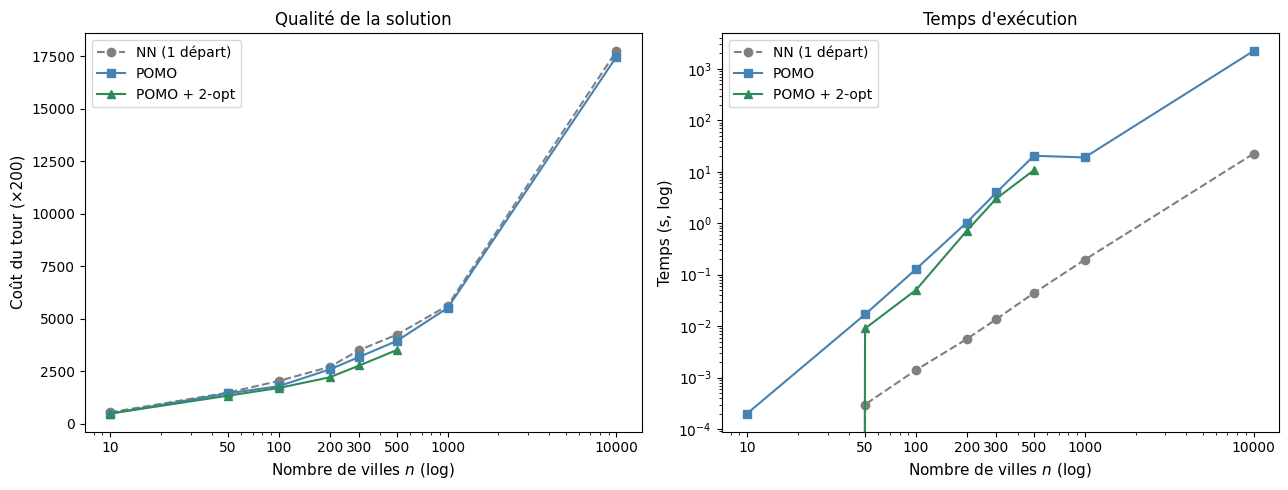

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ns = df.index.tolist()

# ── Coût en fonction de n ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(ns, df["cost_nn"],    "o--", label="NN (1 départ)",  color="gray")
ax.plot(ns, df["cost_pomo"],  "s-",  label="POMO",           color="steelblue")
ax.plot(ns, df["cost_pomo2"], "^-",  label="POMO + 2-opt",   color="seagreen",
        marker="^")
ax.set_xscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Coût du tour (×200)", fontsize=11)
ax.set_title("Qualité de la solution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

# ── Temps d'exécution en fonction de n ───────────────────────────────────
ax = axes[1]
ax.plot(ns, df["t_nn"],    "o--", label="NN (1 départ)",  color="gray")
ax.plot(ns, df["t_pomo"],  "s-",  label="POMO",           color="steelblue")
valid_p2 = df["t_pomo2"].dropna()
ax.plot(valid_p2.index, valid_p2, "^-", label="POMO + 2-opt", color="seagreen")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Temps (s, log)", fontsize=11)
ax.set_title("Temps d'exécution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

plt.tight_layout()
plt.show()